In [ ]:
import boto3
import os
import re

s3_client = boto3.client("s3")

# Define the S3 bucket and prefix
bucket_name = 'bdp-inference-results'
s3_prefix = 'rfc/'

local_dir = "data"
os.makedirs(local_dir, exist_ok=True)

response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=s3_prefix)

pattern = re.compile(r"samples_(\d+)_trees_(\d+)/")

print(f"Listing files in S3 bucket '{bucket_name}' under prefix '{s3_prefix}'...")
if "Contents" in response:
    for obj in response["Contents"]:
        s3_key = obj["Key"]
        
        if s3_key.endswith("/"):
            continue
        
        match = pattern.search(s3_key)
        if match:
            samples = match.group(1)
            trees = match.group(2)
            local_file_name = f"samples_{samples}_trees_{trees}" 
        else:
            # If no hyperparameters are found, use the file name directly
            local_file_name = os.path.basename(s3_key)
        
        local_file_path = os.path.join(local_dir, local_file_name)
        
        print(f"Downloading: {s3_key} as {local_file_name}...")
        s3_client.download_file(bucket_name, s3_key, local_file_path)

print(f"All files downloaded to: {local_dir}")


In [ ]:
import os
import pandas as pd

local_dir = "data"
output_file = "results.csv"

first_file = os.listdir(local_dir)[0]
first_file_path = os.path.join(local_dir, first_file)
merged_df = pd.read_csv(first_file_path, usecols=[0], header=None, names=["label"])

for file_name in os.listdir(local_dir):
    file_path = os.path.join(local_dir, file_name)
    
    if not os.path.isfile(file_path):
        continue
    
    column_name = os.path.splitext(file_name)[0]

    df = pd.read_csv(file_path, usecols=[1], header=None, names=[column_name])
    merged_df = pd.concat([merged_df, df], axis=1)

output_file_path = os.path.join(local_dir, output_file)
merged_df.to_csv(output_file_path, index=False)

print(f"Results merged into: {output_file_path}")

In [ ]:
import os
import pandas as pd


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000) 
pd.set_option("display.max_colwidth", None)

local_dir = "data"
file = "results.csv"
file_path = os.path.join(local_dir, file)


df = pd.read_csv(file_path)

label_col = df["label"]
anomaly_score_cols = df.drop(columns=["label"])

sorted_columns = sorted(
    anomaly_score_cols.columns,
    key=lambda col: (int(col.split("_")[1]), int(col.split("_")[3])) 
)

df = pd.concat([label_col, anomaly_score_cols[sorted_columns]], axis=1)
summary_df = df.iloc[:, 1:].describe().transpose()

print("\nSummary Statistics:")
print(summary_df)



Processing: samples_155_trees_942
Processing: samples_102_trees_578


/home/drwoj/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/drwoj/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/drwoj/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/drwoj/.local/lib/py

Processing: samples_399_trees_988
Processing: samples_374_trees_339
Processing: samples_370_trees_985
Processing: samples_382_trees_152
Processing: samples_168_trees_302
Processing: samples_101_trees_367


/home/drwoj/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/drwoj/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/drwoj/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/drwoj/.local/lib/py

Processing: samples_373_trees_369
Processing: samples_460_trees_135

✅ Saved results to data/best_hyperparameter_results.csv

Overall Best Hyperparameter: samples_155_trees_942 with Threshold 3.12
Final Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.67      0.74     50702
     Anomaly       0.30      0.51      0.37     14034

    accuracy                           0.63     64736
   macro avg       0.56      0.59      0.56     64736
weighted avg       0.71      0.63      0.66     64736



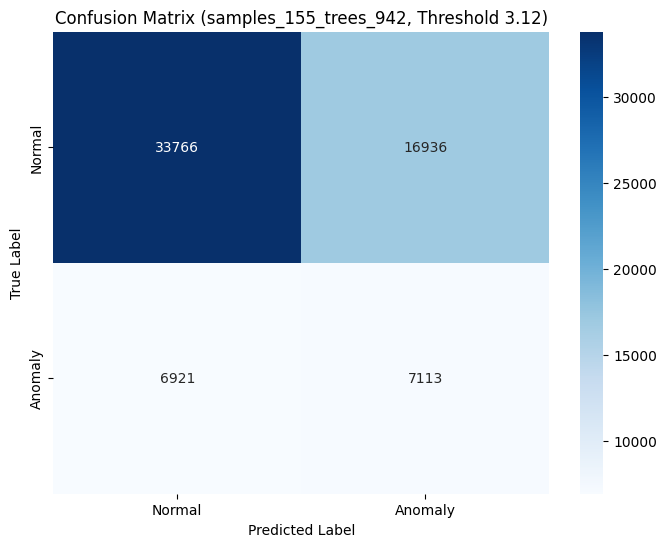

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, fbeta_score, matthews_corrcoef
import json  # For dictionary serialization

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", None)

# Load data
local_dir = "data"
file_path = os.path.join(local_dir, "results.csv")
df = pd.read_csv(file_path)
df["label"] = df["label"].astype(bool)

# Metric calculations
def compute_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"], labels=[False, True], output_dict=True)
    f1 = fbeta_score(y_true, y_pred, beta=1.0)
    recall_normal = report["Normal"]["recall"]
    recall_anomaly = report["Anomaly"]["recall"]
    balance_score = (recall_normal + recall_anomaly) / 2  # Balance between normal and anomaly recall
    mcc = matthews_corrcoef(y_true, y_pred)
    return f1, recall_normal, recall_anomaly, balance_score, mcc, report

# Define search range
search_range = np.arange(3.1, 3.4, 0.02)
best_reports = []

# Iterate over all hyperparameters
for column in df.columns[1:]:  # Assuming first column is label, rest are hyperparameter results
    print(f"Processing: {column}")
    best_f1 = 0
    best_threshold = None
    best_report = None
    
    for threshold in search_range:
        df["is_anomaly"] = df[column] > threshold
        f1, recall_normal, recall_anomaly, balance_score, mcc, report = compute_metrics(df["label"], df["is_anomaly"])
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_report = report

    best_reports.append({
        "hyperparameter": column,
        "threshold": best_threshold,
        "f1_score": best_f1,
        "recall_normal": recall_normal,
        "recall_anomaly": recall_anomaly,
        "balance_score": balance_score,
        "mcc_score": mcc,
        "classification_report": json.dumps(best_report)  # Store full report as a JSON string
    })

# **Save best results for each hyperparameter to CSV**
best_reports_df = pd.DataFrame(best_reports)
csv_path = os.path.join(local_dir, "best_hyperparameter_results.csv")
best_reports_df.to_csv(csv_path, index=False)

print(f"\n✅ Saved results to {csv_path}")

# Find the best hyperparameter overall
best_hyperparam = max(best_reports, key=lambda x: x["f1_score"])
best_threshold = best_hyperparam["threshold"]

# Apply best threshold to classify anomalies
df["is_anomaly"] = df[best_hyperparam["hyperparameter"]] > best_threshold

# Print best classification report
best_classification_report = classification_report(df["label"], df["is_anomaly"], target_names=["Normal", "Anomaly"])
print(f"\nOverall Best Hyperparameter: {best_hyperparam['hyperparameter']} with Threshold {best_threshold:.2f}")
print(f"Final Classification Report:\n{best_classification_report}")

# Generate and display confusion matrix
conf_matrix = pd.crosstab(df["label"], df["is_anomaly"], rownames=["True"], colnames=["Predicted"], dropna=False)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix ({best_hyperparam['hyperparameter']}, Threshold {best_threshold:.2f})")
plt.savefig("confusion_matrix.png")
